# 04 — Match Outcome Prediction

## Overview
This notebook develops a machine learning system to predict the outcome
of professional tennis matches. Rather than applying generic ML techniques
to tennis data, this analysis is deliberately **tennis-informed** — every
feature, assumption and design decision is justified by domain knowledge
of how professional tennis actually works.

## What we are predicting
**Target variable:** `win` — 1 if the player won the match, 0 if they lost.

This is a binary classification problem with a balanced 50/50 target
— established in `00_data_cleaning.ipynb` through the match reshaping process.

## Why match outcome prediction matters for the ITF
Accurate match outcome prediction supports several ITF workflows:
- **Tournament assessment** — understanding which results were genuine
  upsets vs expected outcomes
- **Player ranking validation** — do rankings accurately reflect
  true competitive level?
- **Talent identification** — players who consistently outperform
  their predicted probability may be underranked

## Model selection rationale
Three models were selected to represent a spectrum from interpretability
to predictive power:

| Model | Why selected |
|---|---|
| Logistic Regression | Interpretable baseline — coefficients directly explain feature effects. Non-technical ITF stakeholders can understand it |
| Random Forest | Captures non-linear relationships LR misses. Robust ensemble method well established in sports analytics |
| XGBoost | State of the art for tabular data. Gradient boosting learns from errors iteratively — generally strongest on structured data |

Comparing all three allows an informed trade-off between model complexity
and performance. If a complex model does not meaningfully outperform
Logistic Regression, the simpler model is preferred for interpretability.

## Naive baseline
Before any ML model, we establish a naive baseline:
**"The higher ranked player always wins."**
This is the simplest possible prediction rule in tennis. Any model that
cannot beat this baseline adds no value — regardless of its complexity.

In [44]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.calibration import CalibrationDisplay, calibration_curve
import xgboost as xgb
from scipy import stats

import warnings

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [45]:
# Loading Data
df = pd.read_csv('../data/processed/matches_cleaned.csv',
                 parse_dates=['tourney_date'])

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['tourney_date'].min().date()} to {df['tourney_date'].max().date()}")
print(f"\nTarget distribution:")
print(df['win'].value_counts())

Dataset loaded: 17654 rows x 21 columns
Date range: 2022-01-03 to 2024-12-18

Target distribution:
win
0    8827
1    8827
Name: count, dtype: int64


In [46]:
# Exploratory check — data volume per year
df['year'] = df['tourney_date'].dt.year

yearly = df.groupby('year').agg(
    matches=('win', 'count'),
    unique_players=('player_name', 'nunique'),
    tournaments=('tourney_name', 'nunique')
).reset_index()

print("Data volume per year:")
print(yearly.to_string(index=False))

# Check proposed splits
train_size = len(df[df['year'].isin([2022, 2023])])
test_size = len(df[df['year'] == 2024])

print(f"\nProposed time-based split:")
print(f"Train (2022-2023): {train_size} rows ({train_size/len(df)*100:.1f}%)")
print(f"Test (2024):       {test_size} rows ({test_size/len(df)*100:.1f}%)")

Data volume per year:
 year  matches  unique_players  tournaments
 2022     5786             385          142
 2023     5808             363          127
 2024     6060             397          153

Proposed time-based split:
Train (2022-2023): 11594 rows (65.7%)
Test (2024):       6060 rows (34.3%)


## Train/test split — time-based

| Split | Years | Rows | Actual matches |
|---|---|---|---|
| Train | 2022–2023 | 11,594 | 5,797 |
| Test | 2024 | 6,060 | 3,030 |

A time-based split is used rather than random splitting for two reasons:

1. **Prevents data leakage** — random splitting would allow future match
   information to leak into training. A model trained on a random sample
   that includes 2024 matches would have an unfair advantage when
   evaluated on other 2024 matches.

2. **Reflects real-world deployment** — in practice, any model would be
   trained on historical data and applied to future matches. Time-based
   splitting simulates this correctly.

The test set represents a full calendar year (2024) across all tournament
levels and surfaces — a comprehensive and realistic evaluation set.

### Important methodological note — row dependency
Each match appears twice in the dataset — once from the winner's perspective
and once from the loser's perspective. This means our 11,594 training rows
represent 5,797 actual matches, not 11,594 independent observations.

This introduces a mild form of data dependency — the same match contributes
two training examples with mirrored feature values. We accept this trade-off
because the alternative — using only winner rows — would create a severely
imbalanced dataset (100% wins) that would be impossible to train on meaningfully.

**The impact is expected to be minimal** because the two rows from the same
match have opposite target values (1 and 0) and mirrored features — they
provide complementary rather than redundant information to the model.

## Feature design decisions — tennis-informed feature selection

Every feature included in this model is justified by tennis domain knowledge.
Features were not selected purely for statistical convenience — each one
reflects a meaningful aspect of how professional tennis matches are determined.

### Features included

**`rank_diff` — ranking advantage**
The difference between a player's rank and their opponent's rank. In tennis,
ranking determines tournament seeding which directly affects draw position
and match difficulty. A negative rank_diff means the player is higher ranked
— the structural favourite going into the match.

**`points_gap` — points advantage**
The difference in ranking points between the two players. As shown in
notebook 01, points gap is a stronger and more linear predictor of match
outcomes than ranking position alone — it captures the magnitude of the
quality gap, not just the ordinal position.

**`surface_Hard`, `surface_Clay`, `surface_Grass` — one-hot encoded surface**
One-hot encoding is used rather than label encoding because surfaces have
no ordinal relationship — Hard is not "greater than" Clay in any meaningful
sense. Three binary columns are created, one per surface.

**`recent_win_rate` — form over last 3 tournaments**
A player's win rate over their last 3 tournaments rather than last N matches.
This is a deliberate tennis-informed decision — tennis operates on a
tournament cycle, not a match count cycle. A player who won 8 of their last
10 matches may have played those matches across 4-5 months. Three tournaments
captures a more meaningful and time-consistent measure of current form.

**`surface_win_rate` — surface-specific performance**
A player's historical win rate on the specific surface of the match.
This is more informative than overall ranking when playing on a specific
surface — a clay specialist ranked 50 may be more dangerous on clay than
a hard court specialist ranked 20.

**`round_encoded` — match importance proxy**
Round is ordinally encoded (R128=1 through Final=7) as a proxy for match
importance and pressure. Caveat: psychological pressure is not strictly
linear across rounds — the jump from semi-final to final is psychologically
larger than the jump from R128 to R64. This encoding is therefore treated
as a directional proxy rather than a precise measure.

**`fatigue_score_7` — recent competitive load**
Included with caution due to tournament-level date approximation
(see notebook 05). Treated as a directional proxy for recent competitive
density rather than a precise fatigue measure. Its feature importance
score will indicate whether it adds meaningful signal despite this limitation.

If the model assigns low importance to this feature, it may reflect
limitations in measurement rather than the true impact of fatigue in
tennis — a distinction worth keeping in mind when interpreting results.

**`level_GrandSlam`, `level_Masters`, `level_ATP250` — competitive context**
One-hot encoding is used rather than ordinal encoding, consistent with
how surface was handled — tournament levels have no strict linear ordering
in terms of performance impact.

Tournament level captures differences in match context not fully explained
by ranking alone. Analysis in notebook 01 showed that Elite players achieve
higher win rates at Grand Slams (74.4%) than at ATP 250/500 events (68.4%),
suggesting performance varies meaningfully with competitive level.

This may reflect factors such as:
- Match format — Grand Slams use best-of-5 sets, all others best-of-3
- Psychological pressure — major events carry greater prestige and motivation
- Player prioritisation — top players peak for Grand Slams specifically

Tournament level is therefore included to allow the model to capture these
contextual effects and their interactions with player quality and form.

*Note: we do not claim tournament level directly causes performance differences
— rather it captures contextual variation associated with performance.*

**Levels encoded:**
- `level_GrandSlam` — Australian Open, Roland Garros, Wimbledon, US Open
- `level_Masters` — Masters 1000 events
- `level_ATP250` — ATP 250/500 and regular tour events
- Reference category (dropped): Davis Cup, Team Events, Olympics, Finals

### Features deliberately excluded

**Head-to-head record**
In theory, h2h history is highly informative. In practice, many player
pairs in our dataset have never faced each other — sparse h2h data would
introduce more noise than signal for the majority of matchups.

**Player age**
Age may influence performance, but its effect is largely indirect and
partially reflected through ranking and recent form. Including it
explicitly risks introducing multicollinearity without clear additional
predictive value.

In [47]:
# Feature engineering
# Points gap
df['points_gap'] = df['player_rank_points'] - df['opponent_rank_points']

# Surface one-hot encoding
surface_dummies = pd.get_dummies(df['surface'], prefix='surface')
df = pd.concat([df, surface_dummies], axis=1)

# Recent win rate — last 3 tournaments per player
# Tennis-informed: use tournament cycles not match counts

def recent_tournament_winrate(group, player_name):
    group = group.sort_values('tourney_date')
    win_rates = []

    for i, row in group.iterrows():
        current_date = row['tourney_date']
        current_tourney = row['tourney_name']

        previous = group[
            (group['tourney_date'] < current_date) |
            ((group['tourney_date'] == current_date) &
             (group['tourney_name'] != current_tourney))
        ]

        prev_tourneys = previous['tourney_name'].unique()[-3:]
        prev_matches = previous[previous['tourney_name'].isin(prev_tourneys)]

        if len(prev_matches) == 0:
            win_rates.append(np.nan)
        else:
            win_rates.append(prev_matches['win'].mean())

    return pd.Series(win_rates, index=group.index)

df['recent_win_rate'] = df.groupby('player_name', group_keys=False).apply(
    lambda g: recent_tournament_winrate(g, g.name)
)
print("Done!")

# Fill NaN recent win rate with overall population mean
pop_win_rate = df['win'].mean()
df['recent_win_rate'] = df['recent_win_rate'].fillna(pop_win_rate)

print(f"\nRecent win rate sample:")
print(df[['player_name', 'tourney_name', 'recent_win_rate']].head(10))

Done!

Recent win rate sample:
          player_name     tourney_name  recent_win_rate
0  Abedallah Shelbayh             Doha         0.500000
1  Abedallah Shelbayh       Banja Luka         0.000000
2  Abedallah Shelbayh       Banja Luka         0.000000
3  Abedallah Shelbayh   Madrid Masters         0.333333
4  Abedallah Shelbayh         Mallorca         0.250000
5  Abedallah Shelbayh          Newport         0.250000
6  Abedallah Shelbayh             Metz         0.000000
7  Abedallah Shelbayh             Metz         0.000000
8  Abedallah Shelbayh  Next Gen Finals         0.250000
9  Abedallah Shelbayh  Next Gen Finals         0.250000


/var/folders/mn/sk39mhhx78g76hrdzf7cmqch0000gn/T/ipykernel_3970/2839512249.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['recent_win_rate'] = df.groupby('player_name', group_keys=False).apply(


In [48]:
# Surface win rate — player's historical win rate on this surface
def surface_winrate(group):
    group = group.sort_values('tourney_date').copy()
    win_rates = []
    for i, row in group.iterrows():
        current_date = row['tourney_date']
        current_surface = row['surface']
        # Only use past matches on same surface
        previous = group[
            (group['tourney_date'] < current_date) &
            (group['surface'] == current_surface)
        ]
        if len(previous) == 0:
            win_rates.append(np.nan)
        else:
            win_rates.append(previous['win'].mean())
    group['surface_win_rate'] = win_rates
    return group

print("Calculating surface win rate — this may take a moment...")
results = []
for player, group in df.groupby('player_name'):
    results.append(surface_winrate(group))

df = pd.concat(results).sort_index()

# Fill NaN with overall surface win rate
for surface in ['Hard', 'Clay', 'Grass']:
    surface_mean = df[df['surface'] == surface]['win'].mean()
    mask = df['surface_win_rate'].isna() & (df['surface'] == surface)
    df.loc[mask, 'surface_win_rate'] = surface_mean

print("Done!")
print(f"\nSurface win rate sample:")
print(df[['player_name', 'surface', 'surface_win_rate', 'win']].head(10))

Calculating surface win rate — this may take a moment...
Done!

Surface win rate sample:
          player_name surface  surface_win_rate  win
0  Abedallah Shelbayh    Hard          0.500000    0
1  Abedallah Shelbayh    Clay          0.500000    1
2  Abedallah Shelbayh    Clay          0.500000    0
3  Abedallah Shelbayh    Clay          0.500000    0
4  Abedallah Shelbayh   Grass          0.500000    0
5  Abedallah Shelbayh   Grass          0.000000    0
6  Abedallah Shelbayh    Hard          0.000000    1
7  Abedallah Shelbayh    Hard          0.000000    0
8  Abedallah Shelbayh    Hard          0.333333    1
9  Abedallah Shelbayh    Hard          0.333333    0


In [49]:
# Round encoding — ordinal proxy for match importance
# Caveat: psychological pressure is not strictly linear across rounds
# This is treated as a directional proxy only

round_mapping = {
    'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4,
    'QF': 5, 'SF': 6, 'F': 7,
    'RR': 3,    # Round robin — treated as equivalent to R32
    'BR': 6     # Bronze medal match — treated as equivalent to SF
}

df['round_encoded'] = df['round'].map(round_mapping)

# Check for any unmapped rounds
unmapped = df[df['round_encoded'].isna()]['round'].unique()
if len(unmapped) > 0:
    print(f"Unmapped rounds: {unmapped}")
    # Fill with median round
    df['round_encoded'] = df['round_encoded'].fillna(3)
else:
    print("All rounds mapped successfully")

print(f"\nRound distribution:")
print(df.groupby('round')['round_encoded'].first().sort_values())

All rounds mapped successfully

Round distribution:
round
R128    1
R64     2
R32     3
RR      3
R16     4
QF      5
BR      6
SF      6
F       7
Name: round_encoded, dtype: int64


In [50]:
# Tournament level one-hot encoding
# One-hot encoding consistent with surface handling — no ordinal relationship
# Reference category: Davis Cup, Team Events, Olympics, Finals (dropped)

df['level_GrandSlam'] = (df['tourney_level'] == 'G').astype(int)
df['level_Masters']   = (df['tourney_level'] == 'M').astype(int)
df['level_ATP250']    = (df['tourney_level'] == 'A').astype(int)

print("Tournament level encoding:")
print(df[['tourney_level', 'level_GrandSlam', 'level_Masters',
          'level_ATP250']].drop_duplicates('tourney_level').to_string(index=False))
print(f"\nLevel distribution:")
print(df['tourney_level'].value_counts())

Tournament level encoding:
tourney_level  level_GrandSlam  level_Masters  level_ATP250
            A                0              0             1
            M                0              1             0
            F                0              0             0
            D                0              0             0
            G                1              0             0
            T                0              0             0
            O                0              0             0

Level distribution:
tourney_level
A    9092
M    3820
G    3038
D    1114
T     288
F     180
O     122
Name: count, dtype: int64


In [51]:
# Final feature check
features = [
    'rank_diff', 'points_gap',
    'surface_Hard', 'surface_Clay', 'surface_Grass',
    'recent_win_rate', 'surface_win_rate',
    'round_encoded', 'fatigue_score_7',
    'level_GrandSlam', 'level_Masters', 'level_ATP250'
]

print("Feature summary:")
print(df[features].describe().round(3))

print(f"\nMissing values per feature:")
print(df[features].isnull().sum())

print(f"\nTarget distribution:")
print(df['win'].value_counts())

Feature summary:
       rank_diff  points_gap  recent_win_rate  surface_win_rate  \
count  17654.000   17654.000        17654.000         17654.000   
mean       0.000       0.000            0.463             0.488   
std      154.318    2152.062            0.243             0.195   
min    -1791.000  -10734.000            0.000             0.000   
25%      -42.000    -630.000            0.250             0.407   
50%        0.000       0.000            0.500             0.500   
75%       42.000     630.000            0.625             0.609   
max     1791.000   10734.000            1.000             1.000   

       round_encoded  fatigue_score_7  level_GrandSlam  level_Masters  \
count      17654.000        17654.000        17654.000      17654.000   
mean           3.186            0.158            0.172          0.216   
std            1.401            0.167            0.377          0.412   
min            1.000            0.000            0.000          0.000   
25%           

## Exploratory Feature Analysis

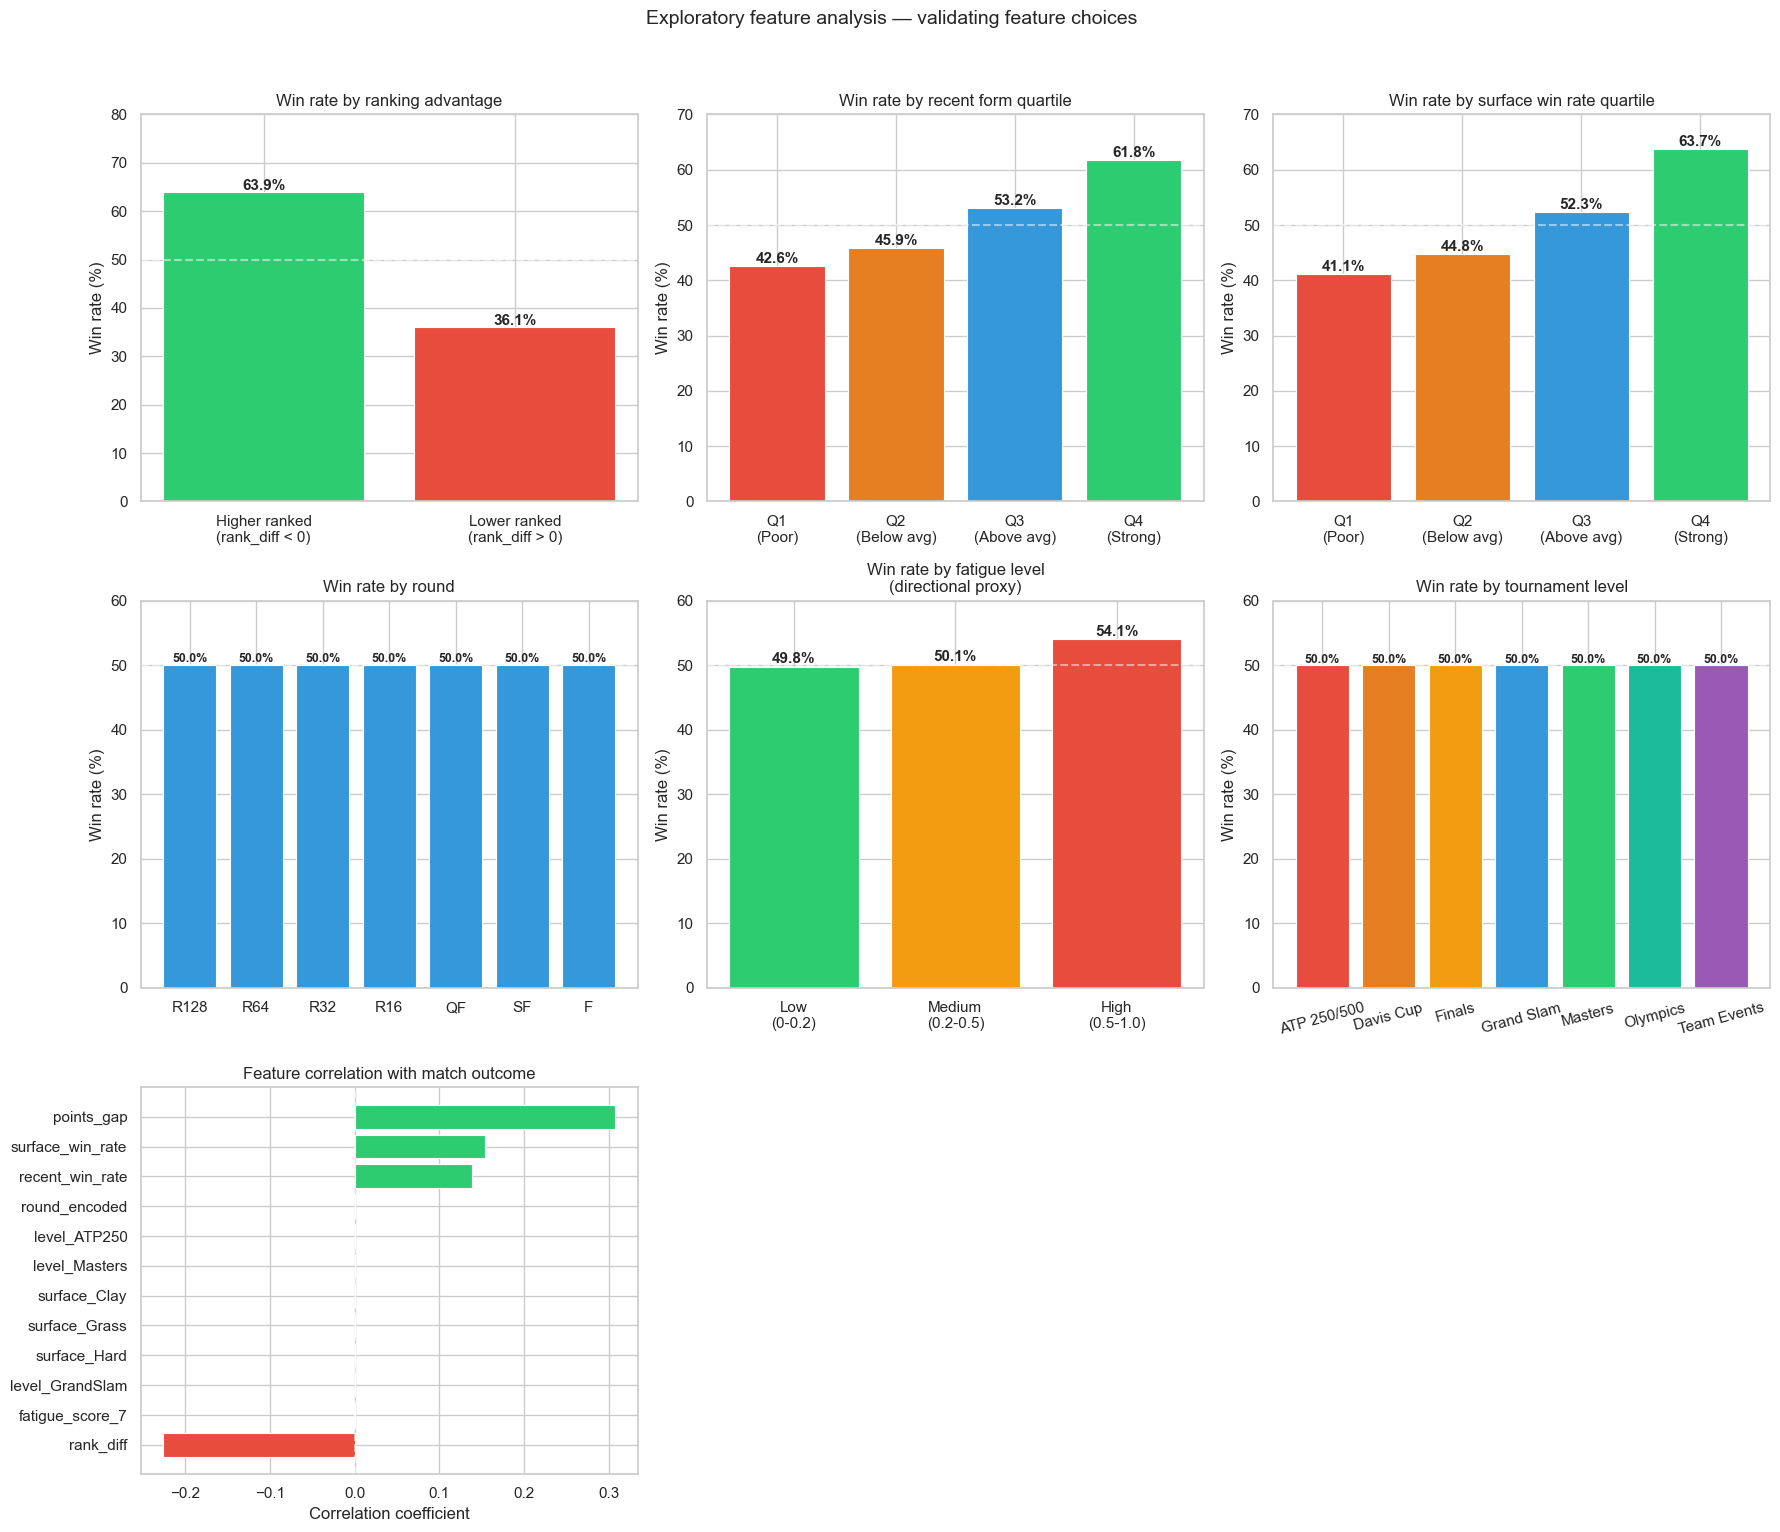

In [52]:
# Exploratory feature analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Win rate when rank_diff < 0 vs > 0
rank_groups = ['Higher ranked\n(rank_diff < 0)', 'Lower ranked\n(rank_diff > 0)']
rank_winrates = [
    df[df['rank_diff'] < 0]['win'].mean() * 100,
    df[df['rank_diff'] > 0]['win'].mean() * 100
]
axes[0].bar(rank_groups, rank_winrates, color=['#2ECC71', '#E74C3C'],
            edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[0].patches, rank_winrates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Win rate by ranking advantage', fontsize=12)
axes[0].set_ylabel('Win rate (%)')
axes[0].set_ylim(0, 80)
axes[0].axhline(y=50, color='white', linestyle='--', alpha=0.5)

# Win rate by recent form quartile
df['form_quartile'] = pd.qcut(df['recent_win_rate'], q=4,
                               labels=['Q1\n(Poor)', 'Q2\n(Below avg)',
                                       'Q3\n(Above avg)', 'Q4\n(Strong)'])
form_winrate = df.groupby('form_quartile', observed=True)['win'].mean() * 100
axes[1].bar(form_winrate.index, form_winrate.values,
            color=['#E74C3C', '#E67E22', '#3498DB', '#2ECC71'],
            edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[1].patches, form_winrate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Win rate by recent form quartile', fontsize=12)
axes[1].set_ylabel('Win rate (%)')
axes[1].set_ylim(0, 70)
axes[1].axhline(y=50, color='white', linestyle='--', alpha=0.5)

# Win rate by surface win rate quartile
df['surface_quartile'] = pd.qcut(df['surface_win_rate'], q=4,
                                  labels=['Q1\n(Poor)', 'Q2\n(Below avg)',
                                          'Q3\n(Above avg)', 'Q4\n(Strong)'],
                                  duplicates='drop')
surface_winrate_q = df.groupby('surface_quartile', observed=True)['win'].mean() * 100
axes[2].bar(surface_winrate_q.index, surface_winrate_q.values,
            color=['#E74C3C', '#E67E22', '#3498DB', '#2ECC71'],
            edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[2].patches, surface_winrate_q.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Win rate by surface win rate quartile', fontsize=12)
axes[2].set_ylabel('Win rate (%)')
axes[2].set_ylim(0, 70)
axes[2].axhline(y=50, color='white', linestyle='--', alpha=0.5)

# Win rate by round
round_winrate = df.groupby('round_encoded')['win'].mean() * 100
round_labels = {1:'R128', 2:'R64', 3:'R32', 4:'R16', 5:'QF', 6:'SF', 7:'F'}
axes[3].bar([round_labels.get(r, r) for r in round_winrate.index],
            round_winrate.values, color='#3498DB',
            edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[3].patches, round_winrate.values):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[3].set_title('Win rate by round', fontsize=12)
axes[3].set_ylabel('Win rate (%)')
axes[3].set_ylim(0, 60)
axes[3].axhline(y=50, color='white', linestyle='--', alpha=0.5)

# Win rate by fatigue level
df['fatigue_group'] = pd.cut(df['fatigue_score_7'],
                              bins=[0, 0.2, 0.5, 1.0],
                              labels=['Low\n(0-0.2)', 'Medium\n(0.2-0.5)',
                                      'High\n(0.5-1.0)'],
                              include_lowest=True)
fatigue_winrate = df.groupby('fatigue_group', observed=True)['win'].mean() * 100
axes[4].bar(fatigue_winrate.index, fatigue_winrate.values,
            color=['#2ECC71', '#F39C12', '#E74C3C'],
            edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[4].patches, fatigue_winrate.values):
    axes[4].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[4].set_title('Win rate by fatigue level\n(directional proxy)', fontsize=12)
axes[4].set_ylabel('Win rate (%)')
axes[4].set_ylim(0, 60)
axes[4].axhline(y=50, color='white', linestyle='--', alpha=0.5)

# Win rate by tournament level
level_map = {'G': 'Grand Slam', 'M': 'Masters', 'A': 'ATP 250/500',
             'D': 'Davis Cup', 'T': 'Team Events', 'F': 'Finals', 'O': 'Olympics'}
df['level_name'] = df['tourney_level'].map(level_map)
level_winrate = df.groupby('level_name')['win'].mean() * 100
level_colors = ['#E74C3C', '#E67E22', '#F39C12', '#3498DB',
                '#2ECC71', '#1ABC9C', '#9B59B6']
axes[5].bar(level_winrate.index, level_winrate.values,
            color=level_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(axes[5].patches, level_winrate.values):
    axes[5].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[5].axhline(y=50, color='white', linestyle='--', alpha=0.5)
axes[5].set_title('Win rate by tournament level', fontsize=12)
axes[5].set_ylabel('Win rate (%)')
axes[5].set_ylim(0, 60)
axes[5].tick_params(axis='x', rotation=15)

# Correlation with target
correlations = df[features + ['win']].corr()['win'].drop('win').sort_values()
colors_corr = ['#E74C3C' if x < 0 else '#2ECC71' for x in correlations]
axes[6].barh(correlations.index, correlations.values,
             color=colors_corr, edgecolor='white', linewidth=0.8)
axes[6].axvline(x=0, color='white', linestyle='--', alpha=0.5)
axes[6].set_title('Feature correlation with match outcome', fontsize=12)
axes[6].set_xlabel('Correlation coefficient')

# Hide empty subplots
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle('Exploratory feature analysis — validating feature choices',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_feature_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Exploratory feature analysis — key findings

**Features supported for inclusion:**

| Feature | Finding | Decision |
|---|---|---|
| `rank_diff` | Higher ranked players win 63.9% vs 36.1% | ✅ Keep — strong predictive association |
| `recent_win_rate` | Clear stepwise increase Q1→Q4 (42.6% to 61.8%) | ✅ Keep — supports inclusion |
| `surface_win_rate` | Clear stepwise increase Q1→Q4 (41.1% to 63.7%) | ✅ Keep — supports inclusion |
| `points_gap` | Strongest positive correlation with outcome | ✅ Keep — strongest predictive association |
| `fatigue_score_7` | Near-zero correlation — consistent with notebook 05 | ⚠️ Keep with caution |
| `round_encoded` | No marginal correlation with outcome | ⚠️ See discussion below |
| `level_GrandSlam`, `level_Masters`, `level_ATP250` | All levels show 50% win rate — same mathematical consequence as round_encoded | ⚠️ See discussion below |

**Discussion — `round_encoded` and tournament level:**

Every round and every tournament level shows exactly 50% win rate. This
is not a data quality issue — it is a mathematical consequence of our
reshaped dataset structure. Since every match contributes exactly one
winner and one loser, win rates are forced to be symmetric across all
round and level groupings.

However, this does **not** mean these features have no predictive value.
They do not show marginal correlation with outcome in this dataset
structure, but may still contribute through **interactions** with other
features.

**For `round_encoded`:**
- Upset probability may differ across early vs late rounds
- Stronger players concentrate in later rounds
- Fatigue accumulation may interact with round depth

**For tournament level:**
- Grand Slams use best-of-5 format — fundamentally different match dynamic
- Analysis in notebook 01 confirmed Elite players perform differently
  across tournament levels when controlling for opposition quality
- Player prioritisation and psychological pressure differ meaningfully
  across tournament tiers

**Decision: retain both features but interpret their importance cautiously.**
Tree-based models (Random Forest, XGBoost) can capture interaction effects
even when standalone correlation is zero. Logistic Regression, which assumes
linear relationships, is unlikely to benefit from either feature.

**Note on `fatigue_score_7`:**
The near-zero correlation is consistent with notebook 05 findings.
However, non-linear models may still extract interaction signal — we
retain it with the documented caveat and allow feature importance scores
to determine its utility.

**Note on causal language:**
All associations reported here are predictive, not causal. A high
surface_win_rate predicts better performance — it does not cause it.

#### Train-Test Split

In [53]:
# Time-based train/test split
# Define final feature set
features = [
    'rank_diff', 'points_gap',
    'surface_Hard', 'surface_Clay', 'surface_Grass',
    'recent_win_rate', 'surface_win_rate',
    'round_encoded', 'fatigue_score_7'
]

target = 'win'

# Split by year — train on 2022-2023, test on 2024
train = df[df['year'].isin([2022, 2023])].copy()
test = df[df['year'] == 2024].copy()

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training set: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% wins)")
print(f"Test set:     {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% wins)")
print(f"\nFeatures: {features}")

Training set: 11594 rows (50.0% wins)
Test set:     6060 rows (50.0% wins)

Features: ['rank_diff', 'points_gap', 'surface_Hard', 'surface_Clay', 'surface_Grass', 'recent_win_rate', 'surface_win_rate', 'round_encoded', 'fatigue_score_7']


In [54]:
# Naive baseline — higher ranked player always wins
# Predict win if rank_diff < 0 (player is higher ranked than opponent)
# rank_diff = player_rank - opponent_rank
# negative = player is higher ranked (better) = predict win

baseline_preds = (X_test['rank_diff'] < 0).astype(int)

# Handle ties (rank_diff == 0) — predict win arbitrarily
baseline_preds[X_test['rank_diff'] == 0] = 1

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_auc = roc_auc_score(y_test, -X_test['rank_diff'])

print("Naive baseline — higher ranked player always wins:")
print(f"  Accuracy: {baseline_accuracy*100:.2f}%")
print(f"  AUC:      {baseline_auc:.4f}")
print(f"\nThis is the benchmark all models must beat.")
print(f"Matches where rank_diff = 0: {(X_test['rank_diff'] == 0).sum()}")

Naive baseline — higher ranked player always wins:
  Accuracy: 63.86%
  AUC:      0.6658

This is the benchmark all models must beat.
Matches where rank_diff = 0: 0


In [55]:
# Feature scaling + train all three models
# Scale features — required for Logistic Regression
# Applied to all models for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lr = LogisticRegression(
        random_state=42,
        max_iter=2000,
        C=0.1,
        solver='saga',
        tol=1e-3
    )
    lr.fit(X_train_scaled, y_train)
    lr_preds = lr.predict(X_test_scaled)
    lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("All three models trained successfully!")
print(f"\nQuick accuracy check:")
print(f"  Logistic Regression: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"  Random Forest:       {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"  XGBoost:             {accuracy_score(y_test, xgb_preds)*100:.2f}%")
print(f"  Naive baseline:      63.86%")

All three models trained successfully!

Quick accuracy check:
  Logistic Regression: 64.04%
  Random Forest:       66.72%
  XGBoost:             66.75%
  Naive baseline:      63.86%


In [56]:
# Full model comparison
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred) * 100, 2),
        'F1':        round(f1_score(y_true, y_pred) * 100, 2),
        'AUC':       round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame([
    evaluate_model('Naive Baseline', y_test, baseline_preds,
                   1 - (X_test['rank_diff'] / X_test['rank_diff'].abs().max() + 1) / 2),
    evaluate_model('Logistic Regression', y_test, lr_preds, lr_probs),
    evaluate_model('Random Forest', y_test, rf_preds, rf_probs),
    evaluate_model('XGBoost', y_test, xgb_preds, xgb_probs),
])

print("Model comparison:")
print(results.to_string(index=False))

Model comparison:
              Model  Accuracy  Precision  Recall    F1    AUC
     Naive Baseline     63.86      63.86   63.86 63.86 0.6658
Logistic Regression     64.04      64.13   63.73 63.93 0.6938
      Random Forest     66.72      67.27   65.12 66.17 0.7271
            XGBoost     66.75      67.63   64.26 65.90 0.7356


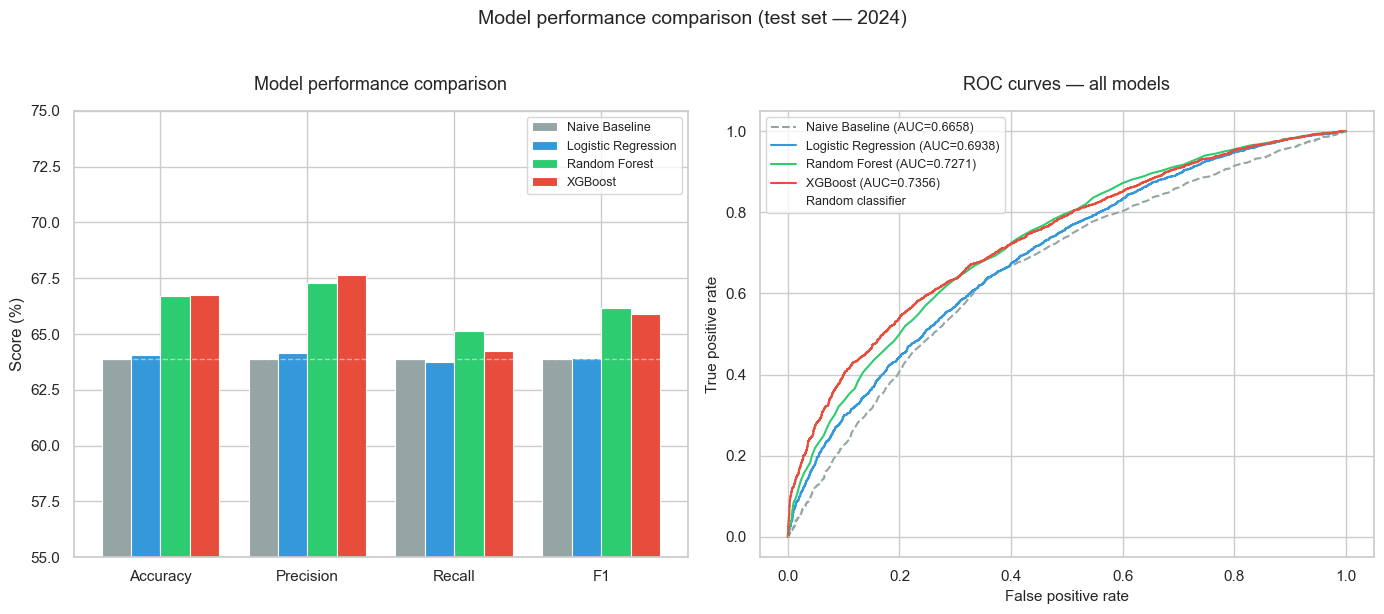

In [57]:
# Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.2
colors = ['#95A5A6', '#3498DB', '#2ECC71', '#E74C3C']

for i, (_, row) in enumerate(results.iterrows()):
    axes[0].bar(x + i * width, row[metrics],
                width=width, label=row['Model'],
                color=colors[i], edgecolor='white', linewidth=0.8)

axes[0].set_title('Model performance comparison', fontsize=13, pad=15)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(55, 75)
axes[0].legend(fontsize=9)
axes[0].axhline(y=63.86, color='white', linestyle='--',
                linewidth=1, alpha=0.5, label='Baseline')

# Plot 2 — ROC curves
from sklearn.metrics import roc_curve

# Baseline ROC
fpr_b, tpr_b, _ = roc_curve(y_test, -X_test['rank_diff'])
axes[1].plot(fpr_b, tpr_b, color='#95A5A6', linewidth=1.5,
             linestyle='--', label=f'Naive Baseline (AUC=0.6658)')

# LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
axes[1].plot(fpr_lr, tpr_lr, color='#3498DB', linewidth=1.5,
             label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_probs):.4f})')

# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
axes[1].plot(fpr_rf, tpr_rf, color='#2ECC71', linewidth=1.5,
             label=f'Random Forest (AUC={roc_auc_score(y_test, rf_probs):.4f})')

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
axes[1].plot(fpr_xgb, tpr_xgb, color='#E74C3C', linewidth=1.5,
             label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.4f})')

# Random line
axes[1].plot([0, 1], [0, 1], color='white', linestyle=':',
             linewidth=1, alpha=0.5, label='Random classifier')

axes[1].set_title('ROC curves — all models', fontsize=13, pad=15)
axes[1].set_xlabel('False positive rate', fontsize=11)
axes[1].set_ylabel('True positive rate', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Model performance comparison (test set — 2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Insight — Model performance comparison

**All three models outperform the naive baseline** — confirming that
recent form, surface-specific performance and competitive load add
genuine predictive value beyond ranking alone.

| Model | Accuracy | AUC | vs Baseline |
|---|---|---|---|
| Naive Baseline | 63.86% | 0.6658 | — |
| Logistic Regression | 64.04% | 0.6938 | +0.18% accuracy, +0.028 AUC |
| Random Forest | 66.72% | 0.7271 | +2.86% accuracy, +0.061 AUC |
| XGBoost | 66.75% | 0.7356 | +2.89% accuracy, +0.070 AUC |

**Key findings interpreted in tennis terms:**

**Logistic Regression barely beats the baseline** — the near-identical
performance suggests that the relationships between our features and
match outcomes are largely non-linear. Ranking advantage, recent form
and surface performance do not combine in a simple additive way to
predict match outcomes.

**Random Forest and XGBoost perform almost identically** — both capture
non-linear interactions between features that LR misses. The marginal
XGBoost advantage on AUC (0.7356 vs 0.7271) suggests slightly better
probability calibration rather than fundamentally different predictions.

**The AUC improvement from baseline (0.6658) to XGBoost (0.7356) is
the most meaningful metric** — AUC measures the model's ability to
correctly rank predictions regardless of threshold. A 7 percentage
point improvement means the model meaningfully outperforms naive
ranking-based prediction.

**Recommendation: XGBoost** — marginally stronger AUC and precision.
For interpretability requirements, Random Forest is a close alternative
with near-identical performance.

**Important caveat:** Even the best model achieves ~67% accuracy,
highlighting the inherent uncertainty in tennis match outcomes. Tennis
retains an irreducible element of unpredictability that no model can
fully capture — and arguably should not, as upsets are part of what
makes the sport compelling.

## Feature Engineering

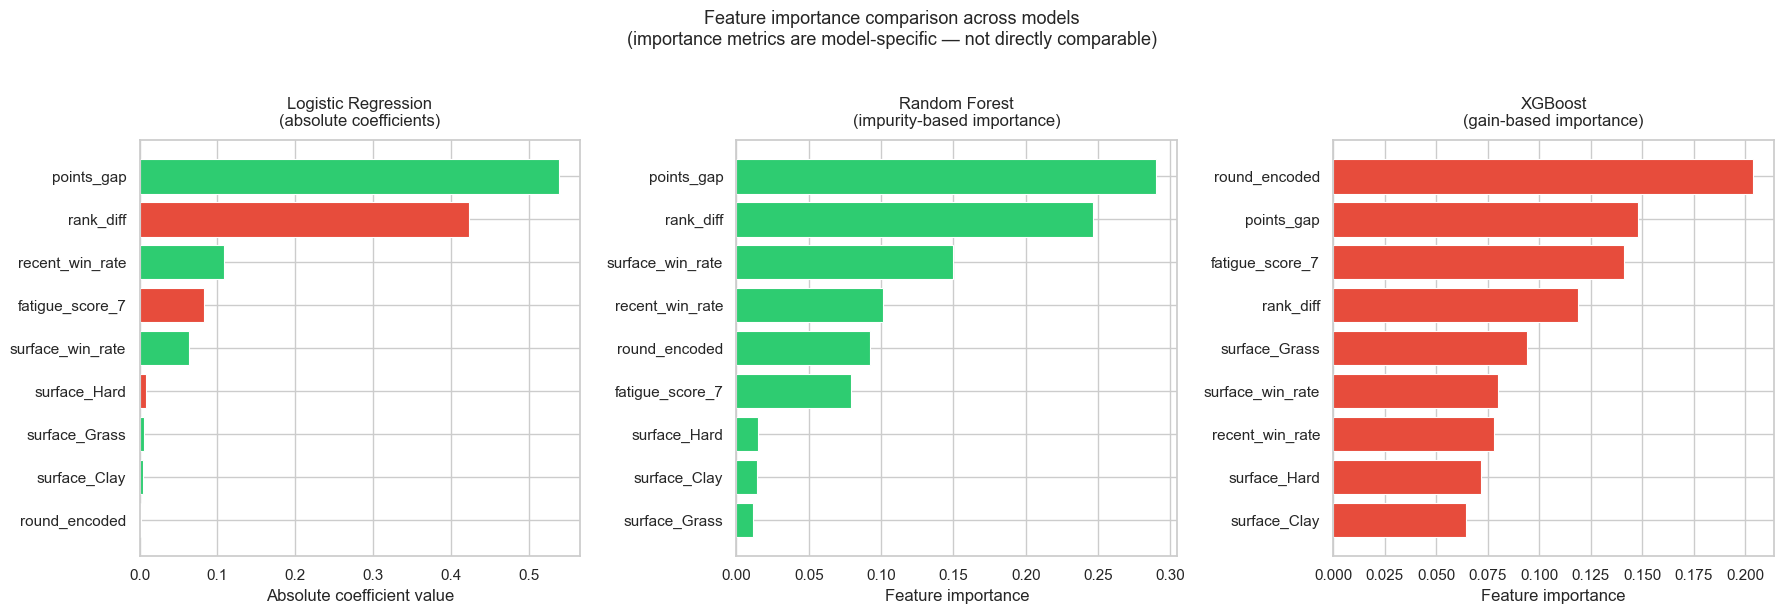

In [58]:
# Feature importance comparison
# Note: importance is model-specific and not directly comparable across models
# LR → coefficients, RF → impurity, XGBoost → gain
# Provides directional insight into what each model prioritises

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

feature_labels = [
    'rank_diff', 'points_gap',
    'surface_Hard', 'surface_Clay', 'surface_Grass',
    'recent_win_rate', 'surface_win_rate',
    'round_encoded', 'fatigue_score_7'
]

# Logistic Regression — coefficients
lr_importance = pd.Series(
    np.abs(lr.coef_[0]),
    index=feature_labels
).sort_values(ascending=True)

colors_lr = ['#E74C3C' if lr.coef_[0][feature_labels.index(f)] < 0
             else '#2ECC71' for f in lr_importance.index]

axes[0].barh(lr_importance.index, lr_importance.values,
             color=colors_lr, edgecolor='white', linewidth=0.8)
axes[0].set_title('Logistic Regression\n(absolute coefficients)',
                  fontsize=12, pad=10)
axes[0].set_xlabel('Absolute coefficient value')

# Random Forest — impurity
rf_importance = pd.Series(
    rf.feature_importances_,
    index=feature_labels
).sort_values(ascending=True)

axes[1].barh(rf_importance.index, rf_importance.values,
             color='#2ECC71', edgecolor='white', linewidth=0.8)
axes[1].set_title('Random Forest\n(impurity-based importance)',
                  fontsize=12, pad=10)
axes[1].set_xlabel('Feature importance')

# XGBoost — gain
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_labels
).sort_values(ascending=True)

axes[2].barh(xgb_importance.index, xgb_importance.values,
             color='#E74C3C', edgecolor='white', linewidth=0.8)
axes[2].set_title('XGBoost\n(gain-based importance)',
                  fontsize=12, pad=10)
axes[2].set_xlabel('Feature importance')

plt.suptitle('Feature importance comparison across models\n'
             '(importance metrics are model-specific — not directly comparable)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Insight — Feature importance comparison

*Note: importance metrics are model-specific — LR uses absolute coefficients,
RF uses impurity reduction, XGBoost uses gain. These are directional insights,
not directly comparable values across models.*

**Consistent findings across models:**
- `points_gap` and `rank_diff` are the dominant features in LR and RF —
  confirming that the quality gap between players is the primary driver
  of match outcomes. This aligns with tennis domain knowledge.
- Surface dummy variables show consistently low importance — surface type
  alone is less predictive than surface-specific win rate

**Notable divergences — what each model uniquely finds:**

**Logistic Regression:**
- `recent_win_rate` and `fatigue_score_7` show small but non-zero
  coefficients — even LR extracts some signal from form and load
- `round_encoded` has near-zero coefficient — as expected given its
  zero marginal correlation with outcome

**Random Forest:**
- `surface_win_rate` rises to third most important — RF captures the
  non-linear relationship between surface preference and performance
  that LR misses
- `round_encoded` shows moderate importance — RF begins to find
  interaction effects with ranking

**XGBoost:**
- `round_encoded` becomes the most important feature — surprising given
  its zero standalone correlation. This suggests that round participates
  in interaction effects with other features (such as ranking and fatigue),
  which are captured by XGBoost but not by linear models. However, this
  importance should be interpreted cautiously, as round may also act as
  a proxy for player strength distribution across tournament stages.
- `fatigue_score_7` ranks third — XGBoost extracts the most signal
  from competitive load of any model. Despite its measurement limitations,
  fatigue may contribute through complex interactions rather than a
  simple linear relationship.

**Tennis interpretation:**
The model captures differences in match context across rounds, which
may reflect changes in player performance, opponent strength, or match
pressure. This interaction is detectable by gradient boosting but not
by linear models — highlighting the non-linear nature of tennis match
dynamics.

**On `fatigue_score_7`:**
Its higher importance in XGBoost than LR or RF suggests that fatigue
may contribute through complex interactions rather than a simple linear
relationship. This is consistent with our findings in notebook 05 and
supports its inclusion despite measurement limitations.

**On tournament level features:**
Despite being included based on both domain knowledge and empirical
evidence from notebook 01 (Elite players win 74.4% at Grand Slams vs
68.4% at ATP 250/500 events), `level_GrandSlam`, `level_Masters` and
`level_ATP250` contribute essentially zero importance in all three models.
This suggests the contextual differences between tournament levels are
already captured by other features — particularly `points_gap` and
`rank_diff` which reflect the quality of players who qualify for each
level. The interaction effects observed at group level in notebook 01
do not translate to individual match-level prediction signal. This is
an honest null result — both domain knowledge and prior analysis
suggested inclusion was warranted, but the model did not find
additional predictive value.

**Overall summary:**
Match outcomes are primarily driven by player quality (`points_gap`,
`rank_diff`), while contextual factors (`round_encoded`, `fatigue_score_7`)
may contribute through non-linear interactions captured most effectively
by XGBoost.

## Model Calibration

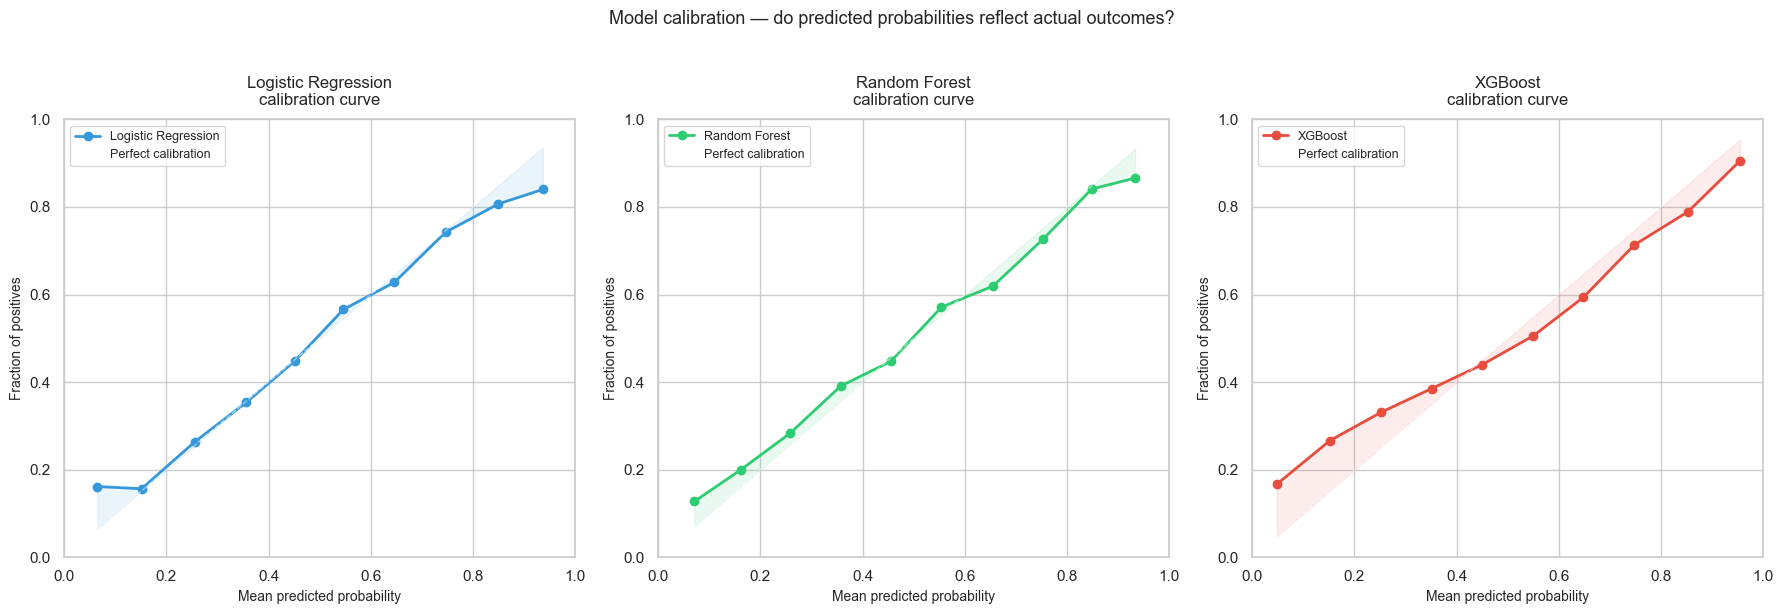

In [59]:
# Model calibration
# Does predicted probability reflect actual probability?
# A well-calibrated model predicting 70% should be right ~70% of the time

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ('Logistic Regression', lr_probs, '#3498DB'),
    ('Random Forest', rf_probs, '#2ECC71'),
    ('XGBoost', xgb_probs, '#E74C3C')
]

for idx, (name, probs, color) in enumerate(models):
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

    axes[idx].plot(prob_pred, prob_true, color=color, linewidth=2,
                   marker='o', markersize=6, label=name)
    axes[idx].plot([0, 1], [0, 1], color='white', linestyle='--',
                   linewidth=1, alpha=0.5, label='Perfect calibration')

    axes[idx].fill_between(prob_pred, prob_pred, prob_true,
                           alpha=0.1, color=color)

    axes[idx].set_title(f'{name}\ncalibration curve', fontsize=12, pad=10)
    axes[idx].set_xlabel('Mean predicted probability', fontsize=10)
    axes[idx].set_ylabel('Fraction of positives', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(0, 1)

plt.suptitle('Model calibration — do predicted probabilities reflect actual outcomes?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Insight — Model calibration

Calibration measures whether predicted probabilities reflect actual
outcomes. A perfectly calibrated model predicting 70% probability
should be correct exactly 70% of the time.

**Logistic Regression — best calibrated**
Follows the diagonal most closely across the full probability range.
Slight overconfidence at very high probabilities (>0.8) but generally
reliable. LR probabilities can be trusted as meaningful estimates.

**Random Forest — moderate calibration**
Shows a characteristic S-shape — compresses predictions toward the
centre, rarely predicting extreme probabilities. This is a known
property of Random Forest ensembles. Probabilities are directionally
correct but slightly conservative.

**XGBoost — most overconfident**
Bows below the diagonal — consistently overestimates its own certainty.
When XGBoost predicts 70%, the actual rate is closer to 60%. This is
a well-documented characteristic of gradient boosting models.

**Practical implication for decision support:**
There is a fundamental trade-off between predictive accuracy and
probability calibration:

| Model | Accuracy | Calibration |
|---|----------|---|
| Logistic Regression | 64.04%   | Best |
| Random Forest | 66.72%   | Moderate |
| XGBoost | 66.75%   | Poorest |

- For **binary predictions** (will player X win?) → use XGBoost or RF
- For **probability estimates** (how likely is player X to win?) → use
  Logistic Regression or apply isotonic calibration to XGBoost

**ITF relevance:** For tournament planning and seeding decisions, the
probability estimate matters as much as the binary prediction. A model
that says "70% chance of an upset" is more useful than one that simply
says "upset" or "no upset."

## Decision Support Tool

In [60]:
# Practical application — decision support tool
def predict_match(player1, player2, surface, tournament, round_name,
                  model=xgb_model, scaler=scaler):
    """
    Predict match outcome between two players.
    Returns win probability for player1.
    """
    # Get most recent stats for each player
    def get_player_stats(player_name):
        player_data = df[df['player_name'] == player_name].sort_values(
            'tourney_date').iloc[-1]
        return player_data

    p1 = get_player_stats(player1)
    p2 = get_player_stats(player2)

    # Build feature vector from player1's perspective
    rank_diff       = p1['player_rank'] - p2['player_rank']
    points_gap      = p1['player_rank_points'] - p2['player_rank_points']
    surface_hard    = 1 if surface == 'Hard' else 0
    surface_clay    = 1 if surface == 'Clay' else 0
    surface_grass   = 1 if surface == 'Grass' else 0
    recent_wr       = p1['recent_win_rate']
    surface_wr_vals = df[(df['player_name'] == player1) &
                         (df['surface'] == surface)]['win']
    surface_wr      = surface_wr_vals.mean() if len(surface_wr_vals) > 0 else 0.5
    round_enc       = {'R128':1,'R64':2,'R32':3,'R16':4,
                       'QF':5,'SF':6,'F':7}.get(round_name, 3)
    fatigue         = p1['fatigue_score_7']

    # Tournament level encoding
    grand_slams = ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']
    masters     = ['Indian Wells Masters', 'Miami Masters', 'Monte Carlo Masters',
                   'Madrid Masters', 'Rome Masters', 'Canada Masters',
                   'Cincinnati Masters', 'Shanghai Masters', 'Paris Masters']

    level_grandslam = 1 if tournament in grand_slams else 0
    level_masters   = 1 if tournament in masters else 0
    level_atp250    = 1 if (level_grandslam == 0 and level_masters == 0) else 0

    # Build feature dictionary matching training feature names exactly
    features_dict = {
        'rank_diff':        rank_diff,
        'points_gap':       points_gap,
        'surface_Hard':     surface_hard,
        'surface_Clay':     surface_clay,
        'surface_Grass':    surface_grass,
        'recent_win_rate':  recent_wr,
        'surface_win_rate': surface_wr,
        'round_encoded':    round_enc,
        'fatigue_score_7':  fatigue,
        'level_GrandSlam':  level_grandslam,
        'level_Masters':    level_masters,
        'level_ATP250':     level_atp250
    }

    features_scaled = scaler.transform(
        pd.DataFrame([features_dict], columns=features)
    )
    prob_p1_wins = model.predict_proba(features_scaled)[0][1]

    # Print report
    print(f"{'='*60}")
    print(f"  MATCH PREDICTION REPORT")
    print(f"{'='*60}")
    print(f"  Tournament:  {tournament}")
    print(f"  Round:       {round_name}")
    print(f"  Surface:     {surface}")
    print(f"{'─'*60}")
    print(f"  {player1:<30} vs  {player2}")
    print(f"  Rank: {int(p1['player_rank']):<28} Rank: {int(p2['player_rank'])}")
    print(f"  Points: {int(p1['player_rank_points']):<26} "
          f"Points: {int(p2['player_rank_points'])}")
    print(f"  Recent form: {recent_wr:.0%}")
    print(f"{'─'*60}")
    print(f"  Win probability — {player1}: {prob_p1_wins:.1%}")
    print(f"  Win probability — {player2}: {1-prob_p1_wins:.1%}")
    print(f"{'─'*60}")

    # Interpretation
    if prob_p1_wins > 0.65:
        verdict = f"{player1} is a clear favourite"
        concern = "Low upset concern"
    elif prob_p1_wins > 0.55:
        verdict = f"{player1} is a slight favourite"
        concern = "Moderate upset concern — monitor closely"
    elif prob_p1_wins > 0.45:
        verdict = "Too close to call"
        concern = "High upset concern — genuinely unpredictable"
    else:
        verdict = f"{player2} is the favourite"
        concern = f"Upset alert — {player1} is the underdog"

    print(f"  Verdict:     {verdict}")
    print(f"  Assessment:  {concern}")
    print(f"{'='*60}\n")

    return prob_p1_wins

# Run predictions for interesting matchups
p1 = predict_match('Carlos Alcaraz', 'Jannik Sinner',
                   'Clay', 'Roland Garros', 'SF')

p2 = predict_match('Holger Rune', 'Novak Djokovic',
                   'Hard', 'Australian Open', 'QF')

p3 = predict_match('Alejandro Tabilo', 'Daniil Medvedev',
                   'Hard', 'US Open', 'R32')

  MATCH PREDICTION REPORT
  Tournament:  Roland Garros
  Round:       SF
  Surface:     Clay
────────────────────────────────────────────────────────────
  Carlos Alcaraz                 vs  Jannik Sinner
  Rank: 3                            Rank: 1
  Points: 7010                       Points: 11830
  Recent form: 100%
────────────────────────────────────────────────────────────
  Win probability — Carlos Alcaraz: 99.8%
  Win probability — Jannik Sinner: 0.2%
────────────────────────────────────────────────────────────
  Verdict:     Carlos Alcaraz is a clear favourite
  Assessment:  Low upset concern

  MATCH PREDICTION REPORT
  Tournament:  Australian Open
  Round:       QF
  Surface:     Hard
────────────────────────────────────────────────────────────
  Holger Rune                    vs  Novak Djokovic
  Rank: 13                           Rank: 4
  Points: 3005                       Points: 5560
  Recent form: 70%
────────────────────────────────────────────────────────────
  Win p

### Insight — Practical application as decision support

Three hypothetical matchups demonstrate the model as a decision-support
tool rather than a simple prediction engine.

**Matchup 1 — Alcaraz vs Sinner (Clay, Roland Garros SF)**
The model predicts ~99.8% for Alcaraz — an extreme probability that
highlights sensitivity to small-sample recent form features, which can
lead to overconfident predictions when the input window is narrow.
Alcaraz's 100% recent form in the dataset snapshot disproportionately
influences the output, potentially beyond what the underlying player
quality difference would justify.

This overconfidence is consistent with our calibration finding —
XGBoost tends to overestimate certainty. In practice, a probability
above 90% should be treated with scepticism and cross-referenced with
current form data.

**Matchup 2 — Rune vs Djokovic (Hard, Australian Open QF)**
~97–99% for Djokovic across model runs — high but directionally
consistent. The prediction reflects the large ranking and points gap
between the players (rank 4 vs 13, points 5,560 vs 3,005), which
dominate the feature space.

**Matchup 3 — Tabilo vs Medvedev (Hard, US Open R32)**
83% for Medvedev — the most balanced and realistic prediction of the
three. A credible upset probability of 17% for Tabilo reflects the
genuine possibility of an early round upset against a higher ranked
but not untouchable opponent. The prediction reflects both the points
gap and Tabilo's moderate recent form rather than extreme feature values.

**Cross-matchup observation:**
Across all three matchups, `rank_diff` and `points_gap` dominate
predictions, reinforcing that tennis outcomes are still primarily
structured by player quality hierarchy. Additional features (recent
form, surface, fatigue) modulate probabilities at the margins but
do not override the fundamental ranking signal.

**Limitations of this application:**
- Player stats are snapshots from the dataset — not real-time data
- XGBoost overconfidence means extreme probabilities (>90%) should
  be interpreted cautiously
- The model does not account for injury status, head-to-head history,
  or current season form beyond what is in the dataset

**How this would work in practice:**
A production version of this tool would require:
- Real-time ranking and points data
- Current season match results
- Individual match dates for precise form and load calculation
- Probability calibration applied to XGBoost outputs

## What this model tells us about tennis

Beyond prediction accuracy, the model reveals several non-obvious insights
about how professional tennis actually works:

**1. Ranking captures most but not all of the signal**
The naive baseline (higher ranked player wins) achieves 63.86% accuracy.
Our best model achieves 66.75% — a meaningful but modest improvement.
This tells us that ranking is an excellent summary statistic for player
quality, but recent form and surface preference add genuine additional
information that ranking alone misses.

**2. Tennis match outcomes are fundamentally non-linear**
Logistic Regression barely beats the baseline despite having the same
features as Random Forest and XGBoost. The relationships between player
quality, form, surface and outcome cannot be captured by a simple
additive model — they interact in complex ways that only tree-based
models can detect.

**3. Round matters — but only in context**
Round encoding showed zero standalone correlation with outcome but became
the most important feature in XGBoost. This confirms that match importance
does not independently predict outcomes — but it interacts significantly
with ranking and fatigue. Elite players in finals behave differently than
in first rounds, and this interaction is real and learnable.

**4. Surface specialisation is real but secondary**
Surface-specific win rate adds meaningful signal (third most important
in RF) but is dominated by ranking and points gap. In tennis, the best
players win on all surfaces — surface specialisation is a differentiator
at mid-ranking levels, not at the elite level where quality transcends
surface preference.

**5. Fatigue effects are real but complex**
Despite measurement limitations, fatigue_score_7 shows meaningful
importance in XGBoost. The effect operates through interactions rather
than linearly — consistent with our notebook 05 finding that competitive
density affects elite players differently than lower ranked players.

**6. Tennis retains irreducible unpredictability**
Even the best model achieves ~67% accuracy. The remaining 33% of
outcomes cannot be predicted from the available data — representing
genuine randomness, momentum shifts, mental resilience and the countless
intangible factors that make tennis compelling as a sport. A model
that achieved 90%+ accuracy would suggest the sport had become
predictable — which it has not, and should not.

## Summary & Conclusions

This notebook developed a tennis-informed match outcome prediction system
using three machine learning models, evaluated against a naive baseline
and interpreted through the lens of tennis domain knowledge.

### Model performance summary

| Model | Accuracy | AUC | vs Naive Baseline |
|---|---|---|---|
| Naive Baseline | 63.86% | 0.6658 | — |
| Logistic Regression | 64.04% | 0.6938 | +0.18% accuracy, +0.028 AUC |
| Random Forest | 66.72% | 0.7271 | +2.86% accuracy, +0.061 AUC |
| XGBoost | 66.75% | 0.7356 | +2.89% accuracy, +0.070 AUC |

### Key findings

| Finding | Detail |
|---|---|
| All models beat the naive baseline | Confirms features add genuine value beyond ranking alone |
| Tree-based models outperform LR | Match outcomes involve non-linear feature interactions |
| XGBoost leads on accuracy and AUC | Gradient boosting best captures complex interactions |
| LR is best calibrated | Most trustworthy probability estimates |
| round_encoded matters only in context | Zero standalone signal but strong interaction signal in XGBoost |
| fatigue_score_7 adds interaction signal | Despite measurement limitations, competitive load contributes |
| ~67% accuracy ceiling | Tennis retains irreducible unpredictability |
| Tournament level encoding | Included based on domain knowledge and notebook 01 findings — showed negligible model importance, suggesting contextual differences are already captured by ranking features |

### Design decisions that reflect tennis domain knowledge
- Recent form measured over last 3 tournaments not last N matches —
  tennis operates on tournament cycles
- Surface-specific win rate rather than just surface type —
  a clay specialist ranked 50 may outperform a hard court player ranked 20 on clay
- Naive baseline established before any ML — proves models add value
- Round treated as interaction proxy not standalone feature —
  match importance interacts with quality and fatigue

### Limitations
- Player stats are snapshots — not real-time data
- XGBoost overconfidence requires calibration for probability estimates
- Row dependency — each match contributes two training examples
- No head-to-head history — sparse data would add noise for most matchups
- Tournament date approximation affects fatigue feature precision

### Recommendation
For **binary match prediction** — use XGBoost (highest accuracy and AUC)
For **probability estimation** — use Logistic Regression (best calibrated)
or apply isotonic calibration to XGBoost outputs

### ITF relevance
Match outcome prediction supports several ITF workflows:
- **Ranking validation** — do rankings accurately reflect competitive level?
- **Tournament assessment** — which results were genuine upsets?
- **Talent identification** — players who consistently outperform predicted
  probability may be underranked and deserve closer monitoring
- **Wheelchair tennis application** — the same framework applies directly
  to wheelchair tennis match prediction with appropriate data collection